# Project 3: Exploring Neural Networks with Keras

**Course:** Fundamentals of AI Enabled Systems  
**Project:** Hands-On Project 3  
**Topic:** Exploring Neural Networks with Keras  
**Tool:** TensorFlow / Keras  
**Environment:** VS Code with Google Colab Runtime  

## Objective

The objective of this project is to explore Artificial Neural Networks using Keras with TensorFlow backend. The notebook demonstrates how neural networks are built, trained, evaluated, and interpreted using a classification dataset. The project focuses on understanding the model architecture, activation functions, training process, evaluation metrics, strengths, limitations, ethical considerations, and real-world applications.

## 1. Import Libraries and Check Environment

In this step, the required Python libraries are imported. TensorFlow and Keras are used to build and train the neural network model. NumPy and Pandas support numerical and tabular operations, while Matplotlib is used for visualization. Scikit-learn metrics are imported to evaluate the model performance using classification metrics such as precision, recall, F1-score, and confusion matrix.

The version check is useful because deep learning libraries can behave differently across versions. Recording the environment also helps make the project more reproducible.

In [26]:
# Project 3: Exploring Neural Networks with Keras
# Step 1: Import required libraries and check versions

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
TensorFlow version: 2.20.0
Keras version: 3.13.2


## 2. Load the Fashion MNIST Dataset

This project uses the Fashion MNIST dataset, which is included with Keras. The dataset contains grayscale images of clothing items such as shirts, shoes, bags, coats, and trousers. Each image is 28 by 28 pixels, and each image belongs to one of 10 classes.

Fashion MNIST is useful for learning neural networks because it is simple enough to train quickly but realistic enough to demonstrate image classification. The goal of the neural network is to learn patterns in the pixel values and correctly classify each image into its clothing category.

In [27]:
# Step 2: Load the Fashion MNIST dataset

fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Full training data shape:", X_train_full.shape)
print("Full training labels shape:", y_train_full.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", len(class_names))
print("Class names:", class_names)

Full training data shape: (60000, 28, 28)
Full training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Inspect a Sample Image

Before training the neural network, it is useful to inspect the dataset visually. Each image in Fashion MNIST is represented as a 28 by 28 matrix of pixel values. The pixel values range from 0 to 255, where 0 represents black and 255 represents white.

This step displays one training image and prints its numerical label as well as the corresponding class name. This helps confirm that the dataset was loaded correctly and that the class labels are mapped properly.

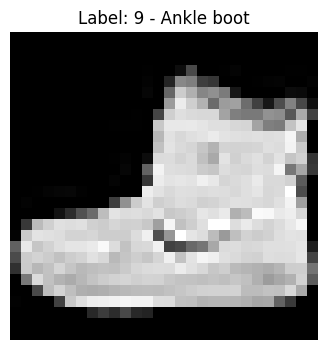

Sample image shape: (28, 28)
Sample label: 9
Class name: Ankle boot
Minimum pixel value: 0
Maximum pixel value: 255


In [28]:
# Step 3: Inspect one sample image and its label

sample_index = 0

plt.figure(figsize=(4, 4))
plt.imshow(X_train_full[sample_index], cmap="gray")
plt.title(f"Label: {y_train_full[sample_index]} - {class_names[y_train_full[sample_index]]}")
plt.axis("off")
plt.show()

print("Sample image shape:", X_train_full[sample_index].shape)
print("Sample label:", y_train_full[sample_index])
print("Class name:", class_names[y_train_full[sample_index]])
print("Minimum pixel value:", X_train_full[sample_index].min())
print("Maximum pixel value:", X_train_full[sample_index].max())

## 4. Visualize Multiple Images from the Dataset

This step displays a small grid of sample images from the training dataset. Visualizing multiple examples helps us understand the variation in the Fashion MNIST dataset. The images include different clothing categories such as shirts, trousers, shoes, bags, and coats.

This section is also useful for the final project report because it demonstrates that the dataset was successfully loaded and reviewed before model training.

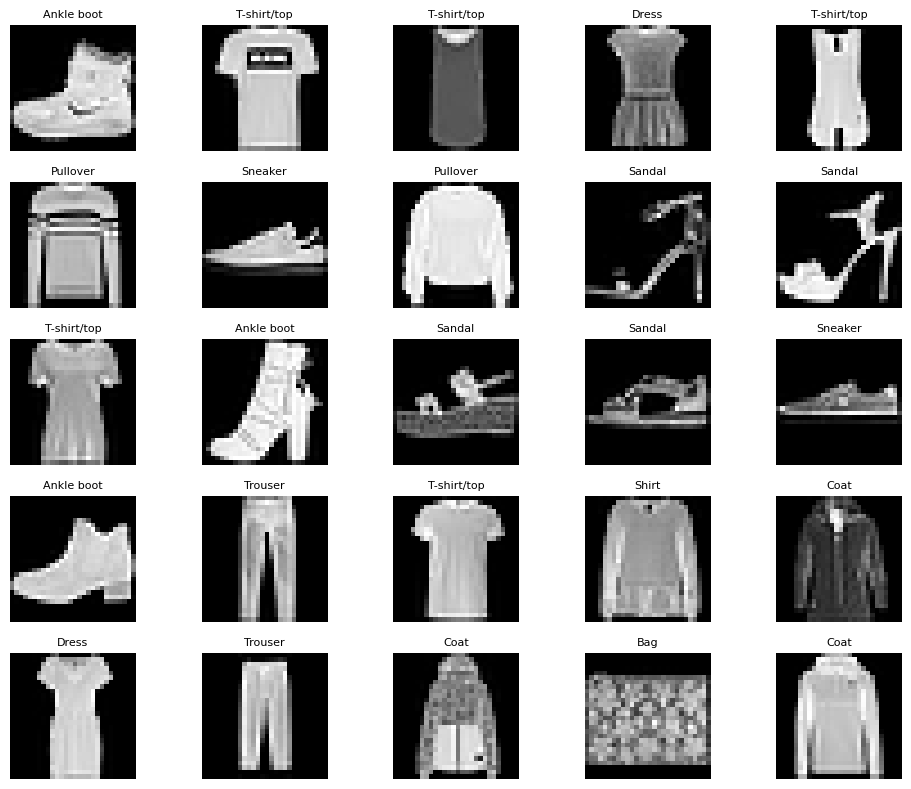

In [29]:
# Step 4: Display multiple sample images from the training dataset

plt.figure(figsize=(10, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Prepare the Training, Validation, and Test Data

The original Fashion MNIST dataset already provides a training set and a test set. However, during model development, it is useful to create a separate validation set from the training data. The validation set helps monitor model performance during training and gives an early indication of whether the model is learning well or overfitting.

The pixel values are also scaled from the original range of 0 to 255 into the range 0 to 1. Scaling improves neural network training because the optimizer can process smaller, normalized values more efficiently.

In [30]:
# Step 5: Create validation set and scale pixel values

X_valid = X_train_full[:5000] / 255.0
y_valid = y_train_full[:5000]

X_train = X_train_full[5000:] / 255.0
y_train = y_train_full[5000:]

X_test_scaled = X_test / 255.0

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Validation data shape:", X_valid.shape)
print("Validation labels shape:", y_valid.shape)

print("Test data shape:", X_test_scaled.shape)
print("Test labels shape:", y_test.shape)

print("Minimum scaled training pixel value:", X_train.min())
print("Maximum scaled training pixel value:", X_train.max())

Training data shape: (55000, 28, 28)
Training labels shape: (55000,)
Validation data shape: (5000, 28, 28)
Validation labels shape: (5000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Minimum scaled training pixel value: 0.0
Maximum scaled training pixel value: 1.0


## 6. Build the Neural Network Model

In this step, a sequential neural network model is created using Keras. A sequential model means the layers are arranged one after another in a simple linear flow.

The first layer flattens each 28 by 28 image into a one-dimensional vector of 784 input values. The hidden layers use the ReLU activation function, which helps the model learn nonlinear patterns. The output layer has 10 neurons because the dataset contains 10 clothing categories. The softmax activation function converts the output values into class probabilities.

In [31]:
# Step 6: Build a neural network model using Keras

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(300, activation="relu"),
    layers.Dense(100, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the Neural Network Model

After building the model architecture, the next step is to compile the model. Compilation defines how the model will learn.

The loss function measures how far the model's predictions are from the correct labels. Since this is a multi-class classification problem and the labels are integer values from 0 to 9, sparse categorical cross-entropy is used. The optimizer controls how the model updates its weights during training. The stochastic gradient descent optimizer is used here. Accuracy is selected as the main evaluation metric because the task is classification.

In [32]:
# Step 7: Compile the neural network model

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 8. Train the Neural Network Model

The model is trained using the prepared training data. During training, the model repeatedly processes the images, compares its predictions with the correct labels, calculates the loss, and updates its weights using the optimizer.

The validation data is used during training to monitor how well the model performs on data it has not directly learned from. This helps identify whether the model is improving, underfitting, or overfitting. In this experiment, the model is trained for 30 epochs.

In [33]:
# Step 8: Train the neural network model

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7615 - loss: 0.7241 - val_accuracy: 0.8232 - val_loss: 0.5249
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8288 - loss: 0.4885 - val_accuracy: 0.8430 - val_loss: 0.4581
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8438 - loss: 0.4434 - val_accuracy: 0.8540 - val_loss: 0.4217
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8539 - loss: 0.4156 - val_accuracy: 0.8634 - val_loss: 0.3986
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8610 - loss: 0.3954 - val_accuracy: 0.8702 - val_loss: 0.3827
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8663 - loss: 0.3792 - val_accuracy: 0.8710 - val_loss: 0.3707
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8712 - loss: 0.3658 - val_accuracy: 0.8730 - val_loss: 0.3611
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8743 - loss: 0.3541 - 

## 9. Visualize Training History

The training history stores the loss and accuracy values from each epoch. Plotting these values helps us understand how the model learned over time.

The accuracy curve shows whether the model's classification performance improved during training. The loss curve shows whether the prediction error decreased. Comparing training and validation curves helps identify possible overfitting or underfitting.

    accuracy      loss  val_accuracy  val_loss
25  0.913509  0.242892        0.8876  0.300025
26  0.914945  0.238842        0.8890  0.299255
27  0.916800  0.234779        0.8900  0.297313
28  0.917745  0.230858        0.8890  0.297815
29  0.919145  0.226878        0.8888  0.297401


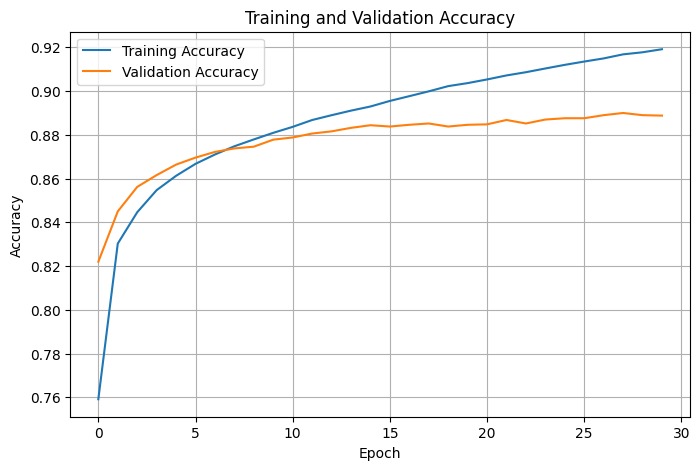

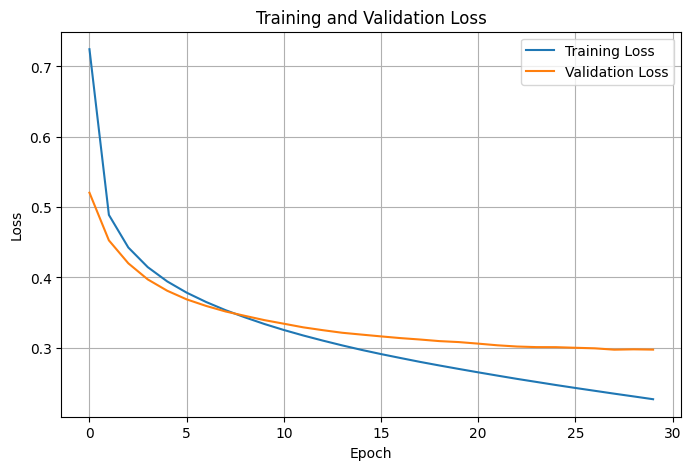

In [ ]:
# Step 9: Plot training and validation accuracy/loss

history_df = pd.DataFrame(history.history)

print(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 10. Evaluate the Model on the Test Set

After training, the model is evaluated on the test dataset. The test set was not used during training or validation, so it provides a better estimate of how the model may perform on new unseen data.

The evaluation returns the test loss and test accuracy. Test accuracy represents the percentage of test images that the neural network classified correctly.

In [ ]:
# Step 10: Evaluate the trained model on the test dataset

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.3308
Test loss: 0.3308
Test accuracy: 0.8844


## 11. Generate Predictions

After evaluating the model, predictions are generated for a small group of test images. The neural network returns probability scores for each of the 10 classes. The class with the highest probability is selected as the final predicted class.

This step helps us interpret the model output in a practical way by comparing predicted clothing categories with the actual labels.

In [ ]:
# Step 11: Generate predictions for test images

X_new = X_test_scaled[:10]
y_proba = model.predict(X_new)
y_pred = np.argmax(y_proba, axis=1)

print("Predicted labels:", y_pred)
print("Actual labels:   ", y_test[:10])

print("\nPredicted class names:")
for i in range(10):
    print(
        f"Image {i}: Predicted = {class_names[y_pred[i]]}, "
        f"Actual = {class_names[y_test[i]]}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted labels: [9 2 1 1 6 1 4 6 5 7]
Actual labels:    [9 2 1 1 6 1 4 6 5 7]

Predicted class names:
Image 0: Predicted = Ankle boot, Actual = Ankle boot
Image 1: Predicted = Pullover, Actual = Pullover
Image 2: Predicted = Trouser, Actual = Trouser
Image 3: Predicted = Trouser, Actual = Trouser
Image 4: Predicted = Shirt, Actual = Shirt
Image 5: Predicted = Trouser, Actual = Trouser
Image 6: Predicted = Coat, Actual = Coat
Image 7: Predicted = Shirt, Actual = Shirt
Image 8: Predicted = Sandal, Actual = Sandal
Image 9: Predicted = Sneaker, Actual = Sneaker


## 12. Visualize Model Predictions

This step displays several test images along with the predicted and actual class names. Visual inspection makes the model results easier to understand. If the predicted label and actual label match, the model classified the image correctly. If they differ, the image represents a model error.

This type of visualization is helpful for interpreting neural network performance beyond numerical accuracy.

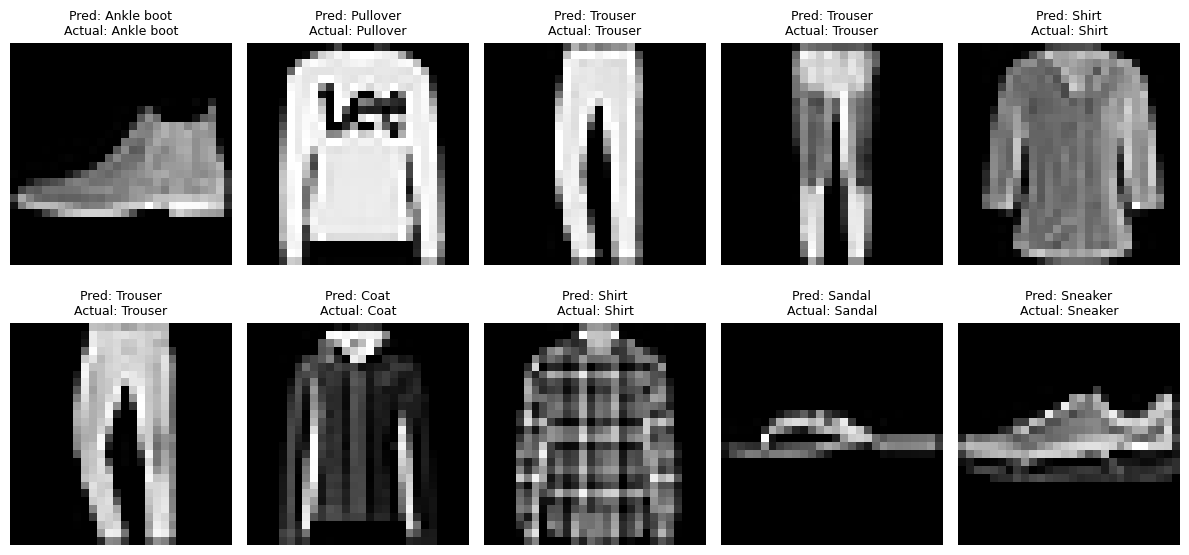

In [ ]:
# Step 12: Visualize predictions for sample test images

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Pred: {class_names[y_pred[i]]}\nActual: {class_names[y_test[i]]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Classification Report

Accuracy gives an overall performance score, but it does not show how the model performs for each individual class. A classification report provides precision, recall, and F1-score for every clothing category.

Precision measures how many predicted labels were correct. Recall measures how many actual examples of a class were correctly found. F1-score balances precision and recall into one metric. These metrics are useful when some classes are harder to classify than others.

In [34]:
# Step 13: Generate classification report for all test images

y_test_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_proba, axis=1)

report = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names
)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.78      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.86      0.79      1000
       Dress       0.91      0.86      0.88      1000
        Coat       0.80      0.81      0.80      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.70      0.71      0.71      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.99      0.95      0.97      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 14. Confusion Matrix

A confusion matrix shows where the model made correct and incorrect predictions. Each row represents the actual class, and each column represents the predicted class. The diagonal values show correct predictions, while values outside the diagonal show misclassifications.

This helps identify which clothing categories are being confused with each other. For example, shirts, coats, pullovers, and T-shirts may be harder to separate because they have similar shapes in small grayscale images.

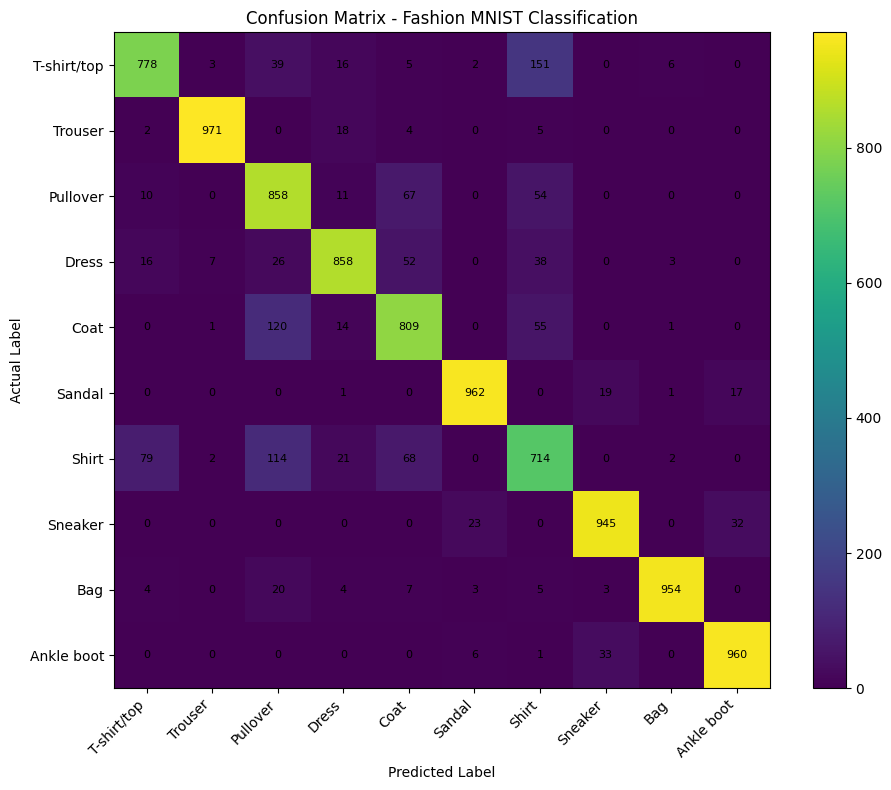

In [35]:
# Step 14: Create and display confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - Fashion MNIST Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

## 15. Summary of Results and Observations

The neural network model was successfully built, trained, and evaluated using the Fashion MNIST dataset. The dataset contained 60,000 training images and 10,000 test images across 10 clothing categories. A validation set of 5,000 images was separated from the training data, leaving 55,000 images for model training.

The model used a simple feedforward neural network architecture. Each 28 by 28 image was flattened into 784 input values. The model included two hidden dense layers with 300 and 100 neurons using ReLU activation. The output layer used 10 neurons with softmax activation to classify the images into one of the 10 categories.

The model was trained for 30 epochs using sparse categorical cross-entropy loss, stochastic gradient descent optimizer, and accuracy as the main metric. The final training accuracy was approximately 91.91%, and the validation accuracy was approximately 88.88%. On the final unseen test set, the model achieved approximately 88.44% accuracy.

The classification report showed that the model performed very well on categories such as Trouser, Bag, Sandal, Sneaker, and Ankle boot. However, the model had more difficulty with visually similar clothing classes such as Shirt, Pullover, Coat, and T-shirt/top. This indicates that a simple dense neural network can learn useful image patterns, but it may struggle when categories have similar shapes and textures.

A potential improvement would be to use a convolutional neural network, which is better suited for image data because it can learn spatial features such as edges, shapes, and local patterns. Additional improvements could include hyperparameter tuning, dropout regularization, early stopping, and experimenting with different optimizers such as Adam.

## 16. Ethical Considerations and Real-World Applications

Neural networks can provide strong predictive performance, but they also raise important ethical concerns. One major concern is bias in training data. If the training data does not represent all groups or situations fairly, the model may produce biased predictions. In real-world systems, this could negatively affect users in areas such as healthcare, finance, hiring, or security.

Another concern is explainability. Neural networks can be difficult to interpret because their decisions are based on many learned weights and nonlinear transformations. This lack of transparency may make it hard for users, managers, or regulators to understand why a model made a specific prediction. Privacy is also important because many AI systems are trained on sensitive personal data.

Despite these concerns, neural networks have many practical applications. In healthcare, they can support medical image analysis and disease risk prediction. In finance, they can help with fraud detection and credit risk modeling. In cybersecurity, they can detect suspicious network behavior. In business intelligence, neural networks can support forecasting, customer segmentation, recommendation systems, and automated decision support.

Responsible AI development requires careful data preparation, model testing, fairness evaluation, privacy protection, and human oversight before deploying neural networks in real-world environments.

## 17. Conclusion

This project provided hands-on experience with building and evaluating a neural network using Keras and TensorFlow. The Fashion MNIST dataset was used to train a multi-class image classification model. The process included loading the dataset, preparing training, validation, and test sets, scaling pixel values, building a neural network architecture, compiling the model, training the model, and evaluating performance.

The model achieved approximately 88.44% test accuracy, showing that even a simple dense neural network can learn meaningful patterns from image data. The results also showed that some classes were easier to classify than others. Items such as trousers, bags, sandals, sneakers, and ankle boots performed strongly, while shirts, pullovers, coats, and T-shirts were more difficult due to visual similarity.

The key takeaway is that neural networks are powerful tools for classification problems, but model design, data quality, evaluation, and ethical considerations are all important. Future improvements could include using convolutional neural networks, dropout, early stopping, hyperparameter tuning, and additional evaluation techniques.